In this Colab we are going to build a Regression Model to predict the price of a home based off of 7 features ie number of bedrooms, number of bathrooms etc

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Here we are going to load in our CSV data in a pandas DataFrame which is the primary data structure used in Pandas.

In [3]:
import pandas as pd


csv_path = '/content/drive/MyDrive/Data/house_price_regression_dataset.csv'
df = pd.read_csv(csv_path)

# View the first few rows of the data
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


Data Preprocessing: Here we will split our features and y target variable and then clean the data before using it.

In [4]:
# 1. Check for missing values in the DataFrame.
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64


In [5]:
# 2. Remove duplicate rows, if any.
df_clean = df.drop_duplicates()
print("\nShape of data after dropping duplicates:", df_clean.shape)


Shape of data after dropping duplicates: (1000, 8)


In [6]:
X = df_clean.drop('House_Price', axis=1)  # Features: all columns except 'price'
y = df_clean['House_Price']               # Target: the house price

In [7]:
# 2. Split the data into training and testing sets (80/20 split).
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% of the data goes to the test set
    random_state=42     # Ensures reproducibility of the split
)

# 3. Scale the features using StandardScaler.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform it.
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform the test data.
X_test_scaled = scaler.transform(X_test)

We'll now build a neural network tailored for regression. In this case:

The input layer will expect data with the number of features I have (for example, 7 after cleaning and feature selection).

We'll include a couple of hidden layers with a ReLU activation to capture non-linear relationships.

The output layer has one neuron without an activation function because we're predicting a continuous value (the house price).

In [16]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Define the model architecture
model = models.Sequential([
    # First hidden layer: 64 neurons, ReLU activation.
    # input_shape is set based on the number of features in our scaled training data.
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),

    # Second hidden layer: 128 neurons, ReLU activation.
    layers.Dense(128, activation='relu'),

    # Output layer: 1 neuron, no activation function for regression.
    layers.Dense(1)
])

# Display the model's architecture
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 64)                  │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,961 (35.00 KB)

 Trainable params: 8,961 (35.00 KB)

 Non-trainable params: 0 (0.00 B)

Adam is a popular optimizer that adapts the learning rate during training, helping the model converge faster.

Loss ('mean_squared_error'):
MSE calculates the average of the squared differences between the predicted and actual values. It heavily penalizes larger errors, making it a common choice for regression problems.

Metrics (['mean_absolute_error']):
MAE computes the average absolute difference between predictions and actual values. It is useful for understanding the average magnitude of the errors in a more interpretable way (e.g., average error in dollars).

In [17]:
model.compile(
    optimizer='adam',             # Adam optimizer for efficient gradient descent
    loss='mean_squared_error',    # MSE is commonly used for regression tasks
    metrics=['mean_absolute_error']  # MAE provides an interpretable error metric (average absolute error)
)

In [18]:
from tensorflow.keras.callbacks import EarlyStopping

# EarlyStopping callback: stops training if the validation loss doesn't improve for 6 consecutive epochs.
early_stop = EarlyStopping(
    monitor='val_loss',       # Monitor the validation loss
    patience=10,               # Number of epochs to wait before stopping if no improvement
    restore_best_weights=True # Revert to the best model weights observed during training
)

# Train the model
history = model.fit(
    X_train_scaled, y_train,         # Training features and target
    epochs=1000,                      # Maximum number of epochs
    validation_data=(X_test_scaled, y_test),  # Evaluate performance on the validation data each epoch
    callbacks=[early_stop]           # Use early stopping to avoid overfitting
)

Epoch 1/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 443080114176.0000 - mean_absolute_error: 617181.5000 - val_loss: 448855441408.0000 - val_mean_absolute_error: 619997.3750
Epoch 2/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 422733742080.0000 - mean_absolute_error: 598142.0000 - val_loss: 448846299136.0000 - val_mean_absolute_error: 619990.3125
Epoch 3/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 439187832832.0000 - mean_absolute_error: 612418.1875 - val_loss: 448827555840.0000 - val_mean_absolute_error: 619976.2500
Epoch 4/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 444932128768.0000 - mean_absolute_error: 615728.3750 - val_loss: 448793542656.0000 - val_mean_absolute_error: 619951.2500
Epoch 5/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 437248458752.0000 - mean_absolute_error: 612682.5000 - val_loss: 448737148928.0000 - val_mean_absolute_error: 619910.3125
Epoch 6/1000
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 435545669632.0000 - mean_abso

Now lets see how the model performs on unseen data. W will use the preprocessed test for this evaluation

In [19]:
# Evaluate the model on the test set
test_loss, test_mae = model.evaluate(X_test_scaled, y_test)

print("Test Loss (MSE):", test_loss)
print("Test MAE:", test_mae)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 144457344.0000 - mean_absolute_error: 9363.4141 
Test Loss (MSE): 134251056.0
Test MAE: 9020.1533203125


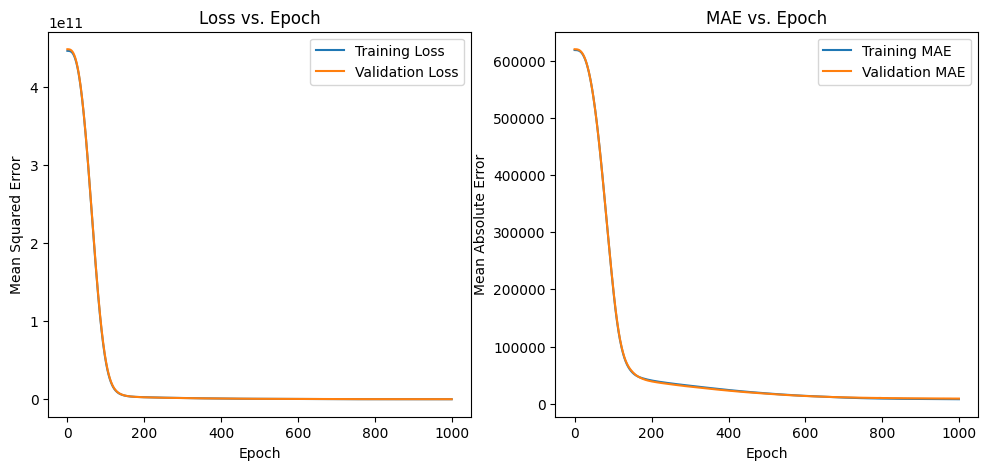

In [20]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(12, 5))

# Plot loss (MSE)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('Loss vs. Epoch')
plt.legend()

# Plot mean absolute error (MAE)
plt.subplot(1, 2, 2)
plt.plot(history.history['mean_absolute_error'], label='Training MAE')
plt.plot(history.history['val_mean_absolute_error'], label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.title('MAE vs. Epoch')
plt.legend()

plt.show()

In [21]:
avg_price = df_clean['House_Price'].mean()
print("Average House Price:", avg_price)

Average House Price: 618861.0186467685


The R² score indicates the proportion of variance in the target variable that is explained by your model. A value of 1 means perfect prediction, while 0 means the model explains none of the variance.

In [22]:
from sklearn.metrics import r2_score

# Generate predictions on the test set
y_pred = model.predict(X_test_scaled)

# Calculate R² score
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
R² Score: 0.9979172595094181


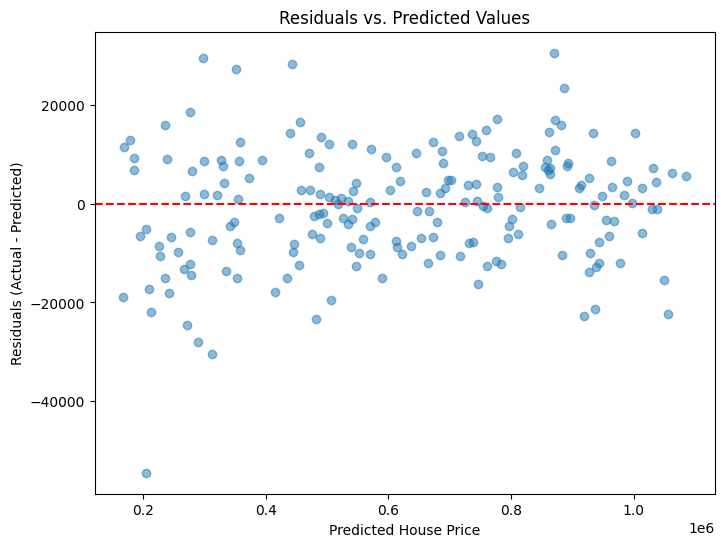

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate residuals
residuals = y_test - y_pred.flatten()  # Flatten in case y_pred is a 2D array

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted House Price")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals vs. Predicted Values")
plt.show()